In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
df10 = pd.read_json("2019-10-perturbed.json")
df20 = pd.read_json("2019-20-perturbed.json")
df30 = pd.read_json("2019-30-perturbed.json")
df50 = pd.read_json("2019-50-perturbed.json")

import numpy as np

from scipy.stats import bootstrap



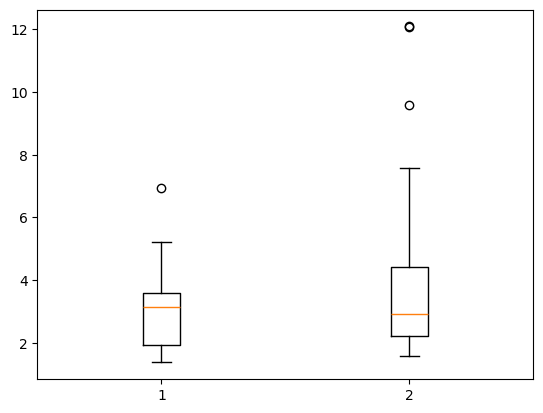

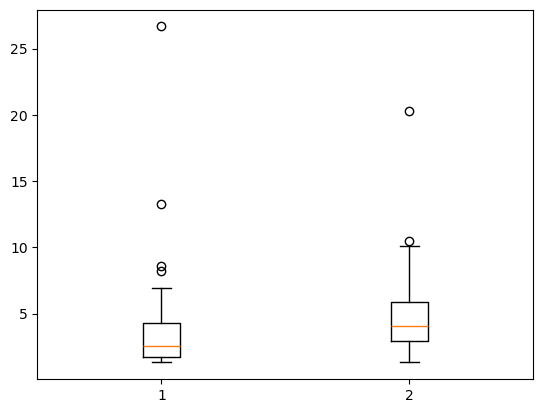

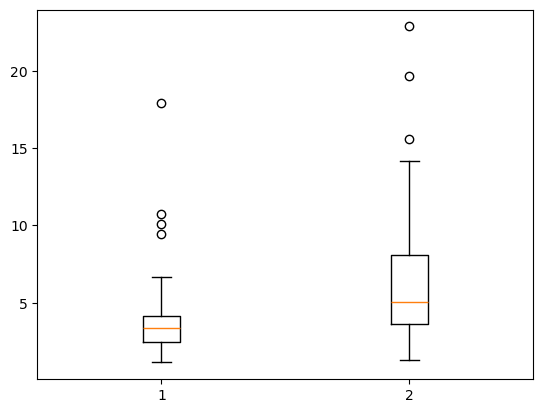

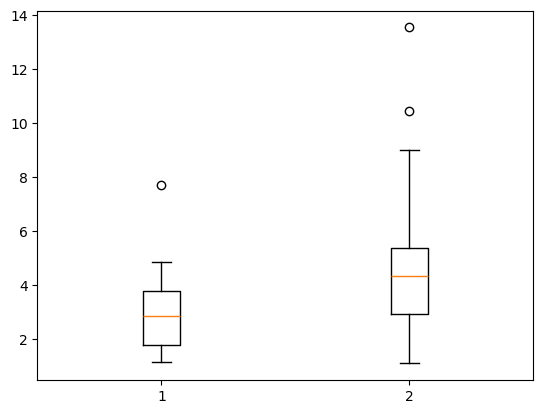

3.153508002848298 2.9383013925839565
Median difference: 0.4011
95% CI: [-0.3134, 1.2218]
[3.153508   2.93830139]
0.659
2.5662780136024814 4.06437484267022
Median difference: 0.8882
95% CI: [0.2810, 1.5360]
[2.56627801 4.06437484]
0.0012
3.348969000046258 5.040762323337281
Median difference: 2.1839
95% CI: [1.2369, 3.4302]
[3.348969   5.04076232]
0.0014
2.853874447194131 4.336296774124544
Median difference: 1.3378
95% CI: [0.8775, 1.7219]
[2.85387445 4.33629677]
0.0004


In [12]:
plt.boxplot(np.sqrt(df10))
plt.show()
plt.boxplot(np.sqrt(df20[df20["sCMOGP"]>0]))
plt.show()
plt.boxplot(np.sqrt(df30))
plt.show()
plt.boxplot(np.sqrt(df50))
plt.show()

for d in [df10, df20, df30, df50]:
    res = bootstrap(
        (np.sqrt(d["GPFITC"][d["sCMOGP"] >0]) - np.sqrt(d["sCMOGP"][d["sCMOGP"] >0]),),
        lambda x: np.median(x),
        n_resamples=10000,
        random_state=42,
        method='percentile'
    )
    median_diff = np.median(np.sqrt(d["GPFITC"][d["sCMOGP"] >0]) - np.sqrt(d["sCMOGP"][d["sCMOGP"] >0]),)
    print(np.median(np.sqrt(d["sCMOGP"])), np.median(np.sqrt(d["GPFITC"])))
    print(f"Median difference: {median_diff:.4f}")
    print(f"95% CI: [{res.confidence_interval.low:.4f}, {res.confidence_interval.high:.4f}]")
    print(np.median(np.sqrt(d[d["sCMOGP"] > 0]), axis=0))
    p_value = 2 * min(
    np.mean(res.bootstrap_distribution <= 0), 
    np.mean(res.bootstrap_distribution >= 0)
    )
    print(p_value)
